# PINN for 1D ODE using JAX

We solve

- u''(x) + π²u(x) = 2π² sin(πx),  x ∈ [0,1]

Boundary conditions:
u(0)=0, u(1)=0  
u'(0)=π, u'(1)=-π

Exact solution:
u(x) = sin(πx)

We solve:
1. Forward PINN (learn u)
2. Inverse PINN (learn λ)


In [24]:
import jax
import jax.numpy as jnp
import optax
import matplotlib.pyplot as plt

pi = jnp.pi

In [25]:
def init_mlp(layers, key):
    params = []
    keys = jax.random.split(key, len(layers)-1)

    for k, (m, n) in zip(keys, zip(layers[:-1], layers[1:])):
        W = jax.random.normal(k, (m, n)) * jnp.sqrt(2/m)
        b = jnp.zeros(n)
        params.append((W, b))

    return params


def mlp(params, x):
    for W, b in params[:-1]:
        x = jnp.tanh(x @ W + b)
    W, b = params[-1]
    return x @ W + b


def u_model(params, x):
    return mlp(params, x.reshape(-1,1)).squeeze()

In [26]:
def dudx(params, x):
    return jax.grad(lambda z: u_model(params, z))(x)


def d2udx2(params, x):
    return jax.grad(lambda z: dudx(params, z))(x)

def residual(params, x):
    return -d2udx2(params, x) + pi**2*u_model(params, x) \
           - 2*pi**2*jnp.sin(pi*x)


In [27]:
def loss_fn(params, xs):
    res = jax.vmap(lambda x: residual(params, x))(xs)
    interior = jnp.mean(res**2)

    bc = (
        u_model(params,jnp.array(0.0))**2 +
        u_model(params,jnp.array(1.0))**2 +
        (dudx(params,jnp.array(0.0))-pi)**2 +
        (dudx(params,jnp.array(1.0))+pi)**2
    )

    return interior + bc

| iteration= 0   |   loss= 737.48004   |   l1_error= 1.3023628
| iteration= 500   |   loss= 4.0678873   |   l1_error= 0.20973475
| iteration= 1000   |   loss= 0.23694569   |   l1_error= 0.05632511
| iteration= 1500   |   loss= 0.030319013   |   l1_error= 0.008051427
| iteration= 2000   |   loss= 0.021848824   |   l1_error= 0.0028948127
| iteration= 2500   |   loss= 0.01664188   |   l1_error= 0.0023150544
| iteration= 3000   |   loss= 0.012319897   |   l1_error= 0.0018622378
| iteration= 3500   |   loss= 0.008823386   |   l1_error= 0.0014635356


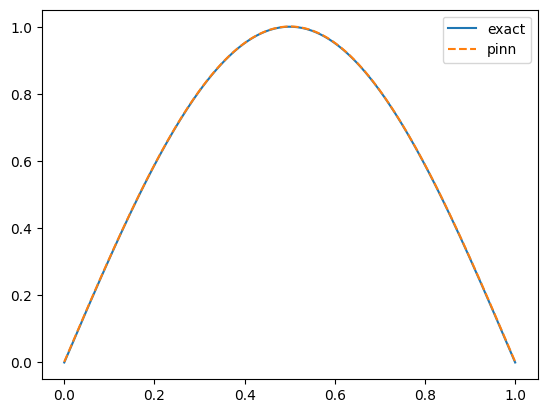

In [28]:
key = jax.random.PRNGKey(0)
params = init_mlp([1, 32, 32, 1], key)

xs = jnp.linspace(0,1,100)
x_plot = jnp.linspace(0,1,200)
u_exact_plot = jnp.sin(pi*x_plot)

opt = optax.adam(1e-3)
opt_state = opt.init(params)

@jax.jit
def step(params, opt_state):
    loss, grads = jax.value_and_grad(loss_fn)(params, xs)
    updates, opt_state = opt.update(grads, opt_state)
    params = optax.apply_updates(params, updates)
    return params, opt_state, loss

for i in range(4000):
    params, opt_state, loss = step(params, opt_state)
    if i % 500 == 0:
        u_pred_plot = jax.vmap(lambda x: u_model(params, x))(x_plot)
        l1_error = jnp.mean(jnp.abs(u_pred_plot - u_exact_plot))
        print( "| iteration=",i,  "  |   loss=", loss, "  |   l1_error=", l1_error)

u_pred = jax.vmap(lambda x: u_model(params, x))(x_plot)
u_exact = jnp.sin(pi*x_plot)

plt.plot(x_plot, u_exact, label="exact")
plt.plot(x_plot, u_pred, "--", label="pinn")
plt.legend()
plt.show()

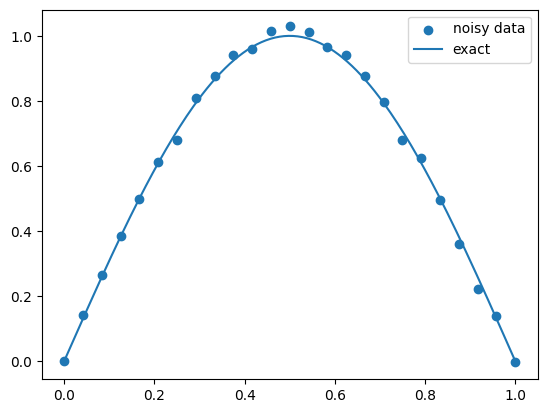

In [29]:
key = jax.random.PRNGKey(42)

n_obs = 25
x_obs = jnp.linspace(0, 1, n_obs)

u_exact_obs = jnp.sin(pi * x_obs)

noise_level = 0.02
noise = noise_level * jax.random.normal(key, x_obs.shape)

u_obs = u_exact_obs + noise

plt.scatter(x_obs, u_obs, label="noisy data")
plt.plot(x_plot, jnp.sin(pi*x_plot), label="exact")
plt.legend()
plt.show()


In [30]:
def residual_inv(params, lam, x):
    return -d2udx2(params, x) + lam*u_model(params, x) \
           - 2*lam*jnp.sin(pi*x)


In [31]:
def loss_inv(theta, xs, x_obs, u_obs):
    params, lam = theta

    res = jax.vmap(lambda x: residual_inv(params, lam, x))(xs)
    physics_loss = jnp.mean(res**2)

    bc_loss = (
        u_model(params,jnp.array(0.0))**2 +
        u_model(params,jnp.array(1.0))**2 +
        (dudx(params,jnp.array(0.0))-pi)**2 +
        (dudx(params,jnp.array(1.0))+pi)**2
    )

    pred_obs = jax.vmap(lambda x: u_model(params, x))(x_obs)
    data_loss = jnp.mean((pred_obs - u_obs)**2)

    return physics_loss + bc_loss + data_loss

In [32]:
lam = jnp.array(3.0)
theta = (params, lam)

opt = optax.adam(1e-3)
opt_state = opt.init(theta)

In [33]:
@jax.jit
def step_inv(theta, opt_state):
    loss, grads = jax.value_and_grad(loss_inv)(
        theta, xs, x_obs, u_obs
    )
    updates, opt_state = opt.update(grads, opt_state)
    theta = optax.apply_updates(theta, updates)
    return theta, opt_state, loss


for i in range(20000):
    theta, opt_state, loss = step_inv(theta, opt_state)
    if i % 500 == 0:
        print( "| iteration=", i, "|  loss=", loss, "|  lambda=", theta[1])

| iteration= 0 |  loss= 23.315876 |  lambda= 3.001
| iteration= 500 |  loss= 2.0718424 |  lambda= 3.406526
| iteration= 1000 |  loss= 1.5822024 |  lambda= 3.8119848
| iteration= 1500 |  loss= 1.2300566 |  lambda= 4.185134
| iteration= 2000 |  loss= 0.9687267 |  lambda= 4.5330105
| iteration= 2500 |  loss= 0.76948136 |  lambda= 4.861922
| iteration= 3000 |  loss= 0.61425006 |  lambda= 5.176624
| iteration= 3500 |  loss= 0.49131066 |  lambda= 5.480574
| iteration= 4000 |  loss= 0.392825 |  lambda= 5.7761025
| iteration= 4500 |  loss= 0.31340507 |  lambda= 6.0644727
| iteration= 5000 |  loss= 0.24904256 |  lambda= 6.3467274
| iteration= 5500 |  loss= 0.1967515 |  lambda= 6.623515
| iteration= 6000 |  loss= 0.15426745 |  lambda= 6.8950996
| iteration= 6500 |  loss= 0.11988845 |  lambda= 7.160845
| iteration= 7000 |  loss= 0.09218433 |  lambda= 7.420381
| iteration= 7500 |  loss= 0.070029676 |  lambda= 7.6726327
| iteration= 8000 |  loss= 0.052492853 |  lambda= 7.9161577
| iteration= 8500 |

Learned lambda: 9.865656
True lambda: 9.869604401089358


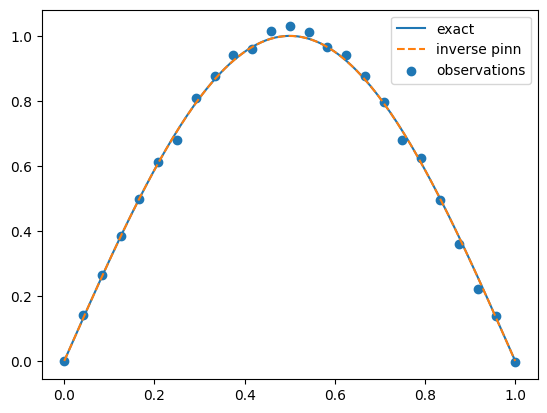

In [34]:
params_learned, lam_learned = theta

print("Learned lambda:", lam_learned)
print("True lambda:", pi**2)

u_pred = jax.vmap(lambda x: u_model(params_learned, x))(x_plot)
u_exact = jnp.sin(pi*x_plot)

plt.plot(x_plot, u_exact, label="exact")
plt.plot(x_plot, u_pred, "--", label="inverse pinn")
plt.scatter(x_obs, u_obs, label="observations")
plt.legend()
plt.show()